# Notebook 04：单因子诊断

本 Notebook 在进行组合回测之前，检验价值、质量、动量和低波动因子的横截面预测能力、时间稳定性、信息重叠程度与排序持续性。主要问题是：**因子能否稳定地把下一期收益较高的股票排在前面？**

## 研究口径

- Rank IC：在每个调仓日，对当期因子值与 `future_return_1m` 计算 Spearman 相关系数。只使用 `is_in_label_sample=True` 的主研究样本，并对每个因子成对删除缺失值。
- 因子相关性与排序自相关：使用信号形成日 `is_eligible=True` 且 `is_buyable=True` 的股票，不依赖下一期标签是否可观测。
- 最小横截面样本数设为 30；不足时该月结果保留为缺失，不填零。
- 因子面板已经在 Notebook 03 中完成逐月去极值、方向统一和 Z-score 标准化；所有主因子均为“数值越大，预期收益越高”。
- 本节是统计诊断，不考虑交易成本，也不把累计 IC 解释为策略净值。

## 1. 环境与参数

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data' / 'processed').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.factors import (
    calculate_average_factor_correlation,
    calculate_factor_rank_autocorrelation,
    calculate_monthly_rank_ic,
    summarize_rank_ic,
)

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FACTOR_PANEL_PATH = PROCESSED_DIR / 'factor_panel_zscore.parquet'
MIN_OBSERVATIONS = 30
ROLLING_WINDOW = 12

FACTOR_LABELS = {
    'ep': 'EP',
    'bp': 'BP',
    'roe': 'ROE',
    'gross_profitability': 'GP',
    'momentum_12_1': 'MOM',
    'low_volatility_60d': 'LOWVOL',
    'size': 'SIZE',
}
DIAGNOSTIC_FACTORS = tuple(FACTOR_LABELS)[:-1]
CORRELATION_FACTORS = tuple(FACTOR_LABELS)

sns.set_theme(style='whitegrid', context='notebook')
print(f'项目目录：{PROJECT_ROOT}')
print(f'Rank IC 因子：{DIAGNOSTIC_FACTORS}')

项目目录：/Users/mac/Desktop/a-share-multifactor
Rank IC 因子：('ep', 'bp', 'roe', 'gross_profitability', 'momentum_12_1', 'low_volatility_60d')


> 注：`MOM` 在本 Notebook 中固定指 README 的主规格 12-1 动量；`momentum_3m` 留到参数稳健性分析中比较。`SIZE` 仅用于相关性和排序持续性诊断，不列入主 Alpha 因子汇总表。

## 2. 读取并校验因子面板

In [2]:
factor_panel = pd.read_parquet(FACTOR_PANEL_PATH)
required_columns = {
    'date', 'stock_code', 'future_return_1m', 'is_in_label_sample',
    'is_eligible', 'is_buyable', *CORRELATION_FACTORS,
}
missing_columns = sorted(required_columns.difference(factor_panel.columns))
assert not missing_columns, f'因子面板缺少字段：{missing_columns}'
assert not factor_panel.duplicated(['date', 'stock_code']).any()

factor_panel['date'] = pd.to_datetime(factor_panel['date'])
label_sample = factor_panel.loc[
    factor_panel['is_in_label_sample'].fillna(False),
    ['date', 'stock_code', 'future_return_1m', *DIAGNOSTIC_FACTORS],
].copy()
signal_sample = factor_panel.loc[
    factor_panel['is_eligible'].fillna(False)
    & factor_panel['is_buyable'].fillna(False),
    ['date', 'stock_code', *CORRELATION_FACTORS],
].copy()

assert label_sample['future_return_1m'].notna().all()
assert np.isfinite(label_sample['future_return_1m']).all()
print(
    f"完整面板：{len(factor_panel):,} 行，"
    f"{factor_panel['date'].nunique()} 个调仓日，"
    f"区间 {factor_panel['date'].min():%Y-%m-%d} 至 "
    f"{factor_panel['date'].max():%Y-%m-%d}"
)
print(
    f"Rank IC 主样本：{len(label_sample):,} 行，"
    f"{label_sample['date'].nunique()} 个可观测持有期"
)
print(f"当期结构诊断样本：{len(signal_sample):,} 行")

完整面板：426,474 行，96 个调仓日，区间 2018-01-31 至 2025-12-31
Rank IC 主样本：383,891 行，95 个可观测持有期
当期结构诊断样本：389,968 行


## 3. 每月 Rank IC 与汇总统计

Rank IC 使用 Spearman 秩相关，更关注选股排序是否正确，而不是因子值与收益之间是否存在线性关系。ICIR 按 README 定义为 `Mean IC / IC Std`，这里不做年化。`IC t-stat` 是均值的常规 t 统计量。

In [3]:
monthly_rank_ic = calculate_monthly_rank_ic(
    label_sample,
    DIAGNOSTIC_FACTORS,
    min_observations=MIN_OBSERVATIONS,
)
ic_summary = summarize_rank_ic(monthly_rank_ic)

assert monthly_rank_ic.index.is_monotonic_increasing
assert monthly_rank_ic.stack().abs().le(1).all()
assert ic_summary['Months'].gt(0).all()

monthly_rank_ic.rename_axis('date').reset_index().to_parquet(
    PROCESSED_DIR / 'factor_rank_ic_monthly.parquet', index=False
)
ic_summary.to_csv(PROCESSED_DIR / 'factor_rank_ic_summary.csv')

required_table = ic_summary.loc[
    list(DIAGNOSTIC_FACTORS),
    ['Mean Rank IC', 'ICIR', 'Positive IC %', 'IC t-stat'],
].rename(index=FACTOR_LABELS)
display(
    required_table.style
    .format({
        'Mean Rank IC': '{:.4f}',
        'ICIR': '{:.3f}',
        'Positive IC %': '{:.1%}',
        'IC t-stat': '{:.2f}',
    })
    .background_gradient(subset=['Mean Rank IC', 'ICIR'], cmap='RdYlGn')
)

,Mean Rank IC,ICIR,Positive IC %,IC t-stat
Factor,,,,
EP,0.0272,0.186,62.1%,1.81
BP,0.0511,0.313,56.8%,3.05
ROE,0.0012,0.008,46.5%,0.08
GP,0.0087,0.075,51.6%,0.73
MOM,-0.0177,-0.113,47.4%,-1.11
LOWVOL,0.0875,0.476,67.4%,4.64


解读时不要只看 t-stat。Mean Rank IC 衡量平均排序方向，ICIR 衡量相对稳定性，Positive IC % 衡量方向正确的频率。统计显著也不等于扣除换手和交易成本后可盈利。

## 4. IC 时间序列：月度、12个月滚动平均与累计 IC

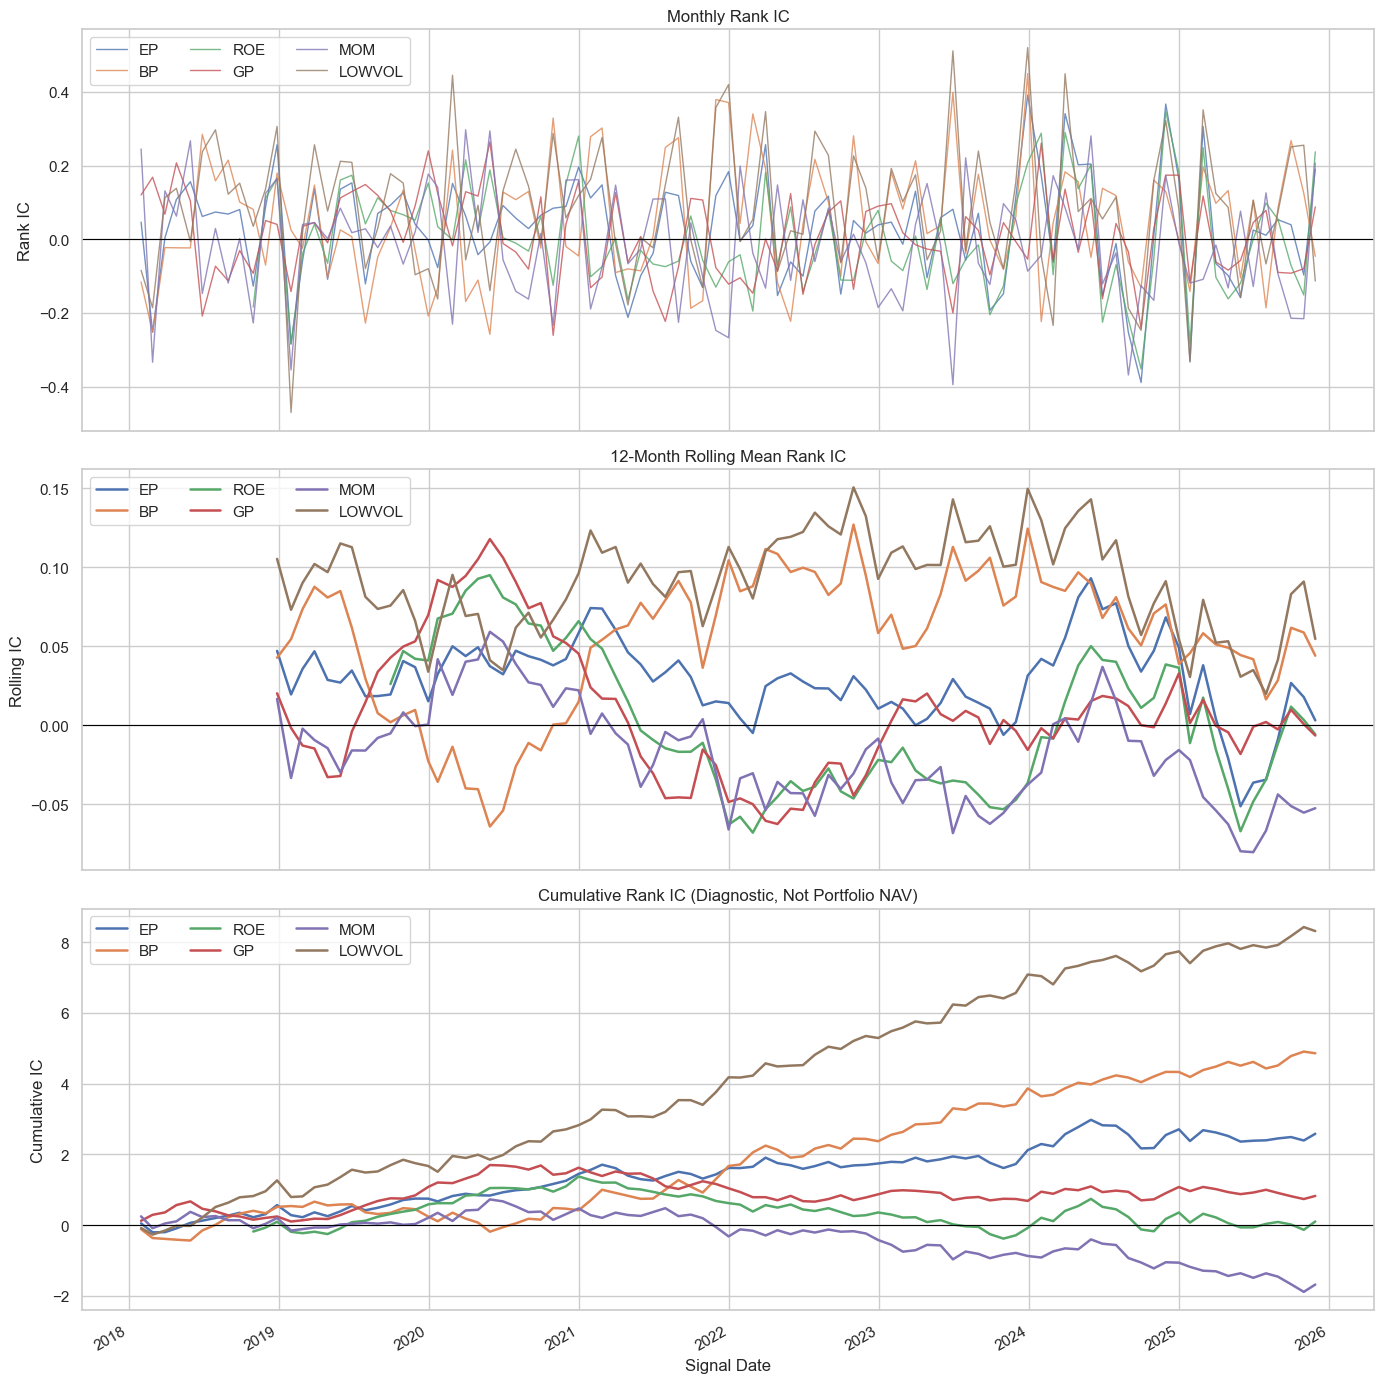

In [4]:
plot_ic = monthly_rank_ic.rename(columns=FACTOR_LABELS)
rolling_ic = plot_ic.rolling(
    ROLLING_WINDOW, min_periods=ROLLING_WINDOW
).mean()
cumulative_ic = plot_ic.cumsum()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
plot_ic.plot(ax=axes[0], linewidth=1.0, alpha=0.78)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Monthly Rank IC')
axes[0].set_ylabel('Rank IC')
axes[0].legend(ncol=3, loc='upper left')

rolling_ic.plot(ax=axes[1], linewidth=1.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('12-Month Rolling Mean Rank IC')
axes[1].set_ylabel('Rolling IC')
axes[1].legend(ncol=3, loc='upper left')

cumulative_ic.plot(ax=axes[2], linewidth=1.8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Cumulative Rank IC (Diagnostic, Not Portfolio NAV)')
axes[2].set_ylabel('Cumulative IC')
axes[2].set_xlabel('Signal Date')
axes[2].legend(ncol=3, loc='upper left')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'factor_rank_ic_timeseries.png', dpi=160, bbox_inches='tight')
plt.show()

累计 IC 只用于观察 IC 长期符号与斜率变化，不是累计收益。若滚动 IC 长时间由正转负、累计 IC 的斜率发生持续反转，才构成结构性失效的预警；短期几个月为负通常不足以下结论。

In [5]:
midpoint = len(monthly_rank_ic) // 2
stability_table = pd.DataFrame({
    'First-half Mean IC': monthly_rank_ic.iloc[:midpoint].mean(),
    'Second-half Mean IC': monthly_rank_ic.iloc[midpoint:].mean(),
    'Latest 12M Mean IC': monthly_rank_ic.tail(ROLLING_WINDOW).mean(),
    'Positive Rolling-12M %': rolling_ic.gt(0).sum().div(rolling_ic.notna().sum()).to_numpy(),
}).rename(index=FACTOR_LABELS)
display(stability_table.style.format({
    'First-half Mean IC': '{:.4f}',
    'Second-half Mean IC': '{:.4f}',
    'Latest 12M Mean IC': '{:.4f}',
    'Positive Rolling-12M %': '{:.1%}',
}).background_gradient(cmap='RdYlGn', axis=0))

,First-half Mean IC,Second-half Mean IC,Latest 12M Mean IC,Positive Rolling-12M %
Factor,,,,
EP,0.0305,0.0239,0.0030,90.5%
BP,0.0276,0.0741,0.0440,88.1%
ROE,0.0179,-0.0121,-0.0058,44.0%
GP,0.0247,-0.0070,-0.0065,54.8%
MOM,-0.0012,-0.0339,-0.0525,26.2%
LOWVOL,0.0799,0.0949,0.0546,100.0%


## 5. 因子相关性

先在每个月的股票横截面上计算 Spearman 因子相关系数，再对月份等权平均。高绝对相关性表示两个因子提供的信息可能重复，但不代表其中任一因子一定有效。

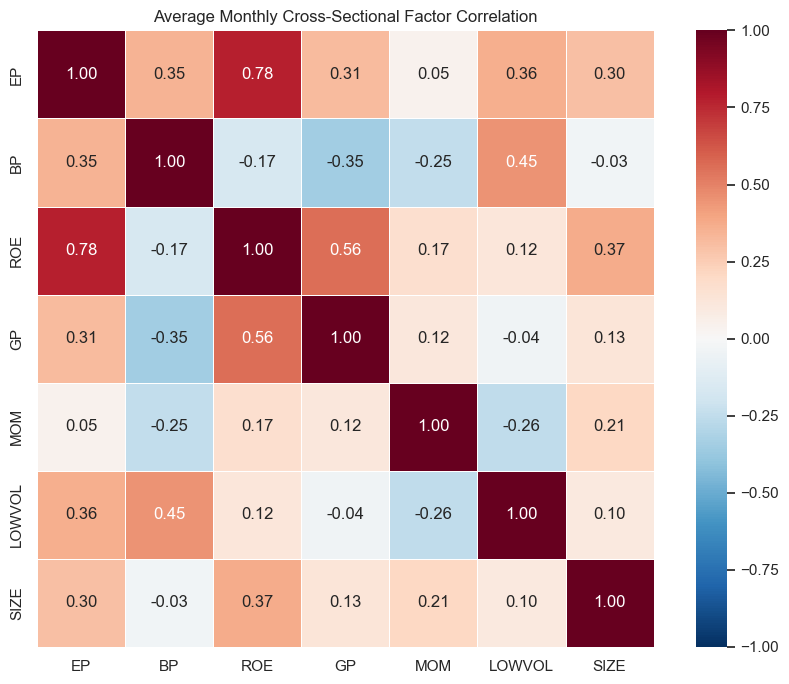

In [6]:
average_factor_correlation = calculate_average_factor_correlation(
    signal_sample,
    CORRELATION_FACTORS,
    method='spearman',
    min_observations=MIN_OBSERVATIONS,
).rename(index=FACTOR_LABELS, columns=FACTOR_LABELS)
average_factor_correlation.to_csv(
    PROCESSED_DIR / 'factor_correlation_spearman.csv'
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    average_factor_correlation,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Average Monthly Cross-Sectional Factor Correlation')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'factor_correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

In [7]:
upper_triangle = average_factor_correlation.where(
    np.triu(np.ones(average_factor_correlation.shape, dtype=bool), k=1)
).stack()
strongest_pairs = (
    upper_triangle.rename('Correlation').to_frame()
    .assign(Absolute=lambda frame: frame['Correlation'].abs())
    .sort_values('Absolute', ascending=False)
    .head(10)
)
display(strongest_pairs.style.format({'Correlation': '{:.3f}', 'Absolute': '{:.3f}'}))

## 6. 因子排序自相关与 Turnover 预警

对相邻调仓日共同存在的股票，计算当期与上期因子排名的 Spearman 相关系数。排序自相关较低意味着候选股票排名变化较快，未来组合可能具有较高换手率；但实际换手还取决于分组边界、持仓数量、缓冲区和调仓频率。

,mean,median,min,max,count
factor,,,,,
BP,0.985,0.986,0.949,0.992,95
EP,0.973,0.993,0.800,0.998,95
GP,0.992,1.000,0.937,1.000,95
LOWVOL,0.869,0.869,0.754,0.954,95
MOM,0.866,0.870,0.634,0.935,95
ROE,0.978,1.000,0.808,1.000,86
SIZE,0.992,0.992,0.986,0.996,95


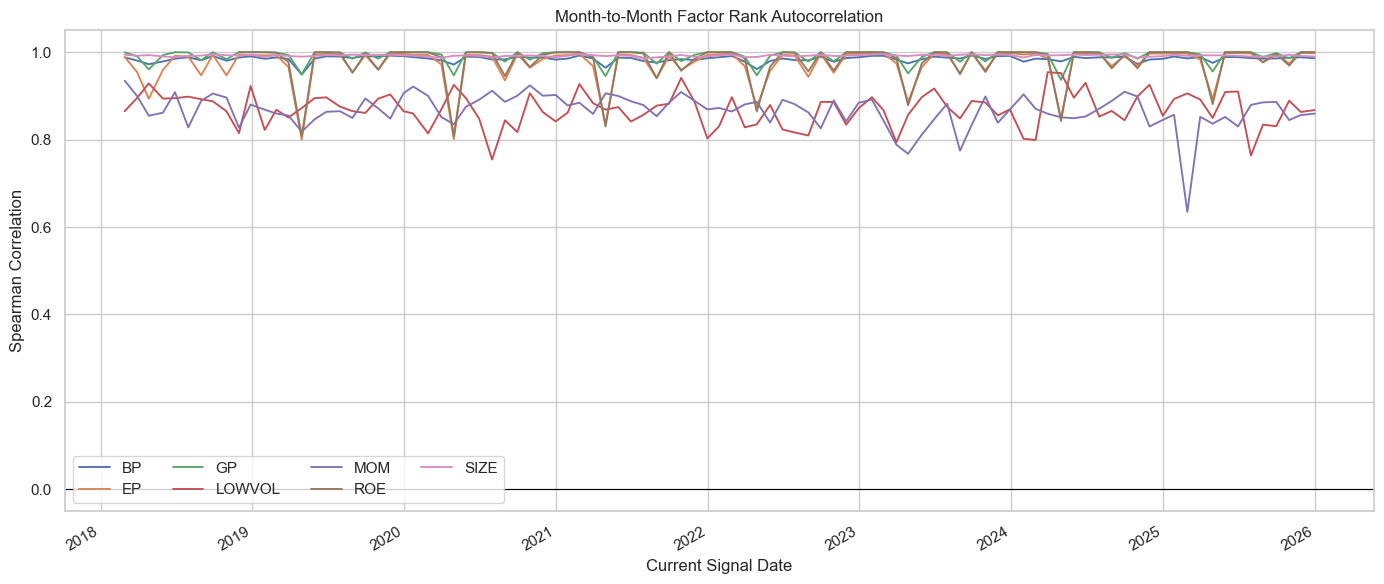

In [8]:
rank_autocorrelation = calculate_factor_rank_autocorrelation(
    signal_sample,
    CORRELATION_FACTORS,
    min_observations=MIN_OBSERVATIONS,
)
rank_autocorrelation.to_parquet(
    PROCESSED_DIR / 'factor_rank_autocorrelation.parquet', index=False
)
autocorrelation_summary = (
    rank_autocorrelation.groupby('factor')['rank_autocorrelation']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .rename(index=FACTOR_LABELS)
)
display(autocorrelation_summary.style.format({
    'mean': '{:.3f}', 'median': '{:.3f}', 'min': '{:.3f}', 'max': '{:.3f}',
}).background_gradient(subset=['mean', 'median'], cmap='YlGn'))

autocorrelation_wide = rank_autocorrelation.pivot(
    index='date', columns='factor', values='rank_autocorrelation'
).rename(columns=FACTOR_LABELS)
fig, ax = plt.subplots(figsize=(14, 6))
autocorrelation_wide.plot(ax=ax, linewidth=1.35)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Month-to-Month Factor Rank Autocorrelation')
ax.set_xlabel('Current Signal Date')
ax.set_ylabel('Spearman Correlation')
ax.legend(ncol=4, loc='lower left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'factor_rank_autocorrelation.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. 结果摘要

In [9]:
best_mean_factor = ic_summary['Mean Rank IC'].idxmax()
best_icir_factor = ic_summary['ICIR'].idxmax()
lowest_persistence_factor = (
    rank_autocorrelation.groupby('factor')['rank_autocorrelation'].mean().idxmin()
)
print(
    f"平均 Rank IC 最高：{FACTOR_LABELS[best_mean_factor]} "
    f"({ic_summary.loc[best_mean_factor, 'Mean Rank IC']:.4f})"
)
print(
    f"ICIR 最高：{FACTOR_LABELS[best_icir_factor]} "
    f"({ic_summary.loc[best_icir_factor, 'ICIR']:.3f})"
)
print(
    f"平均排序持续性最低、换手预警最强："
    f"{FACTOR_LABELS[lowest_persistence_factor]}"
)
print('下一步：在 Notebook 05 用五分位数组合检验排序能力能否转化为经济收益。')

平均 Rank IC 最高：LOWVOL (0.0875)
ICIR 最高：LOWVOL (0.476)
平均排序持续性最低、换手预警最强：MOM
下一步：在 Notebook 05 用五分位数组合检验排序能力能否转化为经济收益。


## 输出文件

数据结果：

- `data/processed/factor_rank_ic_monthly.parquet`
- `data/processed/factor_rank_ic_summary.csv`
- `data/processed/factor_correlation_spearman.csv`
- `data/processed/factor_rank_autocorrelation.parquet`

图形结果：

- `figures/factor_rank_ic_timeseries.png`
- `figures/factor_correlation_heatmap.png`
- `figures/factor_rank_autocorrelation.png`